# 实践项目 09：ECG R 峰检测与跨记录验证

本项目使用 PhysioNet MIT-BIH Arrhythmia Database 中 7 条独立记录的前 5 分钟。记录 100 只用于选择检测参数；记录 101、103、105、106、108、109 保持参数冻结，用于检查算法在不同波形、节律和噪声条件下的表现。

## 任务总览

1. 核对记录、导联、采样率和人工心搏标注。
2. 使用 5—18 Hz 带通滤波和短时能量构造 R 峰候选信号。
3. 只在 record 100 比较阈值分位数和最小峰间距离。
4. 固定参数后逐条评价其余记录，报告 sensitivity、positive predictive value 和 F1。
5. 查看漏检较多的记录，说明固定规则的适用边界。

这里的评价对象是人工标注心搏附近是否检测到峰，不是心律失常分类或临床诊断。

In [1]:
from pathlib import Path  # 管理数据和输出路径
import json  # 保存结果摘要
import numpy as np  # 处理 ECG 数组
import pandas as pd  # 整理逐记录指标
import matplotlib.pyplot as plt  # 绘制波形与指标图
from scipy.signal import butter, sosfiltfilt, find_peaks  # 滤波和峰值检测


def find_project_root():  # 从任意 Notebook 工作目录定位仓库根目录
    for root in [Path.cwd(), *Path.cwd().parents]:
        if (root / 'experience' / 'data' / 'project-10').exists():
            return root
    return Path.cwd()


project_root = find_project_root()


def find_file(name):  # 兼容 Kaggle 数据集和本地仓库
    roots = [Path('/kaggle/input'), project_root, project_root / 'experience' / 'data' / 'project-10']
    for root in roots:
        if root.exists():
            matches = list(root.rglob(name))
            if matches:
                return matches[0]
    raise FileNotFoundError(f'没有找到 {name}，请添加项目 09 数据集。')


bundle = np.load(find_file('mitdb_multirecord_5min.npz'), allow_pickle=True)  # 读取7条真实记录
record_ids = bundle['record_id'].astype(str)
signals = bundle['signal'].astype(np.float32)
sig_names = bundle['sig_name'].astype(str)
sampling_rates = bundle['fs'].astype(float)
annotations = bundle['ann_sample']
output_dir = Path('/kaggle/working') if Path('/kaggle/working').exists() else project_root / 'experience' / 'assets' / 'results' / 'project-10'
output_dir.mkdir(parents=True, exist_ok=True)
print({'records': record_ids.tolist(), 'signal_shape': signals.shape, 'sampling_rates': sampling_rates.tolist()})

{'records': ['100', '101', '103', '105', '106', '108', '109'], 'signal_shape': (7, 108000, 2), 'sampling_rates': [360.0, 360.0, 360.0, 360.0, 360.0, 360.0, 360.0]}


## 任务 1：记录、导联与标注核对

逐条列出输入规模和人工标注数，明确 record 100 与冻结测试记录的用途。

In [2]:
record_table = []  # 保存每条记录的数据摘要
lead_indexes = []  # 保存本次使用的导联索引
for index, record_id in enumerate(record_ids):
    names = sig_names[index].astype(str)
    candidates = np.where(names == 'MLII')[0]
    lead_index = int(candidates[0]) if len(candidates) else 0
    lead_indexes.append(lead_index)
    record_table.append({
        'record': record_id,
        'lead': names[lead_index],
        'samples': int(signals.shape[1]),
        'seconds': float(signals.shape[1] / sampling_rates[index]),
        'annotated_beats': int(len(annotations[index])),
    })
record_table = pd.DataFrame(record_table)
record_table

,record,lead,samples,seconds,annotated_beats
0,100,MLII,108000,300.0,371
1,101,MLII,108000,300.0,342
2,103,MLII,108000,300.0,355
3,105,MLII,108000,300.0,417
4,106,MLII,108000,300.0,331
5,108,MLII,108000,300.0,283
6,109,MLII,108000,300.0,433


## 任务 2：滤波、短时能量与一对一匹配

带通滤波用于突出 QRS 相关频率，平方与移动平均把双向波形转为正的短时能量。一对一匹配避免多个检测峰重复匹配同一人工标注。

In [3]:
def detection_energy(signal, fs):  # 构造用于峰值检测的短时能量
    sos = butter(3, [5, 18], btype='bandpass', fs=fs, output='sos')
    filtered = sosfiltfilt(sos, signal)
    squared = filtered ** 2
    width = max(1, int(0.08 * fs))
    energy = np.convolve(squared, np.ones(width) / width, mode='same')
    return filtered, energy


def one_to_one_match(detected, annotated, tolerance):  # 一对一匹配检测峰和人工标注
    detected = np.asarray(detected, dtype=int)
    annotated = np.asarray(annotated, dtype=int)
    i = j = true_positive = 0
    while i < len(detected) and j < len(annotated):
        delta = int(detected[i] - annotated[j])
        if abs(delta) <= tolerance:
            true_positive += 1
            i += 1
            j += 1
        elif delta < -tolerance:
            i += 1
        else:
            j += 1
    false_positive = len(detected) - true_positive
    false_negative = len(annotated) - true_positive
    return true_positive, false_positive, false_negative


def detect_record(index, quantile, min_distance_seconds):  # 使用同一规则处理任意记录
    fs = float(sampling_rates[index])
    lead = int(lead_indexes[index])
    filtered, energy = detection_energy(signals[index, :, lead].astype(float), fs)
    threshold = float(np.quantile(energy, quantile))
    peaks, _ = find_peaks(energy, height=threshold, distance=int(min_distance_seconds * fs))
    return filtered, energy, peaks

## 任务 3：只在 record 100 选择参数

参数搜索不能查看冻结测试记录的标签表现。选定参数后不再针对单条测试记录调整。

In [4]:
development_index = int(np.where(record_ids == '100')[0][0])  # record 100 只用于参数选择
search_results = []
for quantile in np.arange(0.88, 0.995, 0.005):
    for min_distance in [0.20, 0.22, 0.24, 0.26, 0.28, 0.30]:
        _, _, peaks = detect_record(development_index, quantile, min_distance)
        fs = float(sampling_rates[development_index])
        tp, fp, fn = one_to_one_match(peaks, annotations[development_index], int(0.10 * fs))
        f1 = 2 * tp / max(1, 2 * tp + fp + fn)
        search_results.append({'quantile': float(quantile), 'min_distance': min_distance, 'tp': tp, 'fp': fp, 'fn': fn, 'f1': f1})
best = max(search_results, key=lambda item: (item['f1'], -item['fp'], -item['fn']))
best

{'quantile': 0.88, 'min_distance': 0.2, 'tp': 371, 'fp': 0, 'fn': 0, 'f1': 1.0}

## 任务 4：冻结参数后的跨记录评价

逐条报告指标，避免用总体高分掩盖某些记录上的漏检。

In [5]:
rows = []  # 保存冻结参数后的逐记录表现
all_tp = all_fp = all_fn = 0
for index, record_id in enumerate(record_ids):
    _, _, peaks = detect_record(index, best['quantile'], best['min_distance'])
    fs = float(sampling_rates[index])
    tp, fp, fn = one_to_one_match(peaks, annotations[index], int(0.10 * fs))
    sensitivity = tp / max(1, tp + fn)
    ppv = tp / max(1, tp + fp)
    f1 = 2 * tp / max(1, 2 * tp + fp + fn)
    split = 'development' if record_id == '100' else 'frozen test'
    rows.append({'record': record_id, 'split': split, 'annotated': len(annotations[index]), 'detected': len(peaks), 'tp': tp, 'fp': fp, 'fn': fn, 'sensitivity': sensitivity, 'ppv': ppv, 'f1': f1})
    if split == 'frozen test':
        all_tp += tp; all_fp += fp; all_fn += fn
metrics = pd.DataFrame(rows)
test_summary = {
    'records': int((metrics['split'] == 'frozen test').sum()),
    'sensitivity': all_tp / max(1, all_tp + all_fn),
    'positive_predictive_value': all_tp / max(1, all_tp + all_fp),
    'f1': 2 * all_tp / max(1, 2 * all_tp + all_fp + all_fn),
    'tp': int(all_tp), 'fp': int(all_fp), 'fn': int(all_fn),
}
print(test_summary)
metrics

{'records': 6, 'sensitivity': 0.983341045812124, 'positive_predictive_value': 0.999059708509638, 'f1': 0.9911380597014925, 'tp': 2125, 'fp': 2, 'fn': 36}


,record,split,annotated,detected,tp,fp,fn,sensitivity,ppv,f1
0,100,development,371,371,371,0,0,1.000000,1.000000,1.000000
1,101,frozen test,342,343,341,2,1,0.997076,0.994169,0.995620
2,103,frozen test,355,355,355,0,0,1.000000,1.000000,1.000000
3,105,frozen test,417,417,417,0,0,1.000000,1.000000,1.000000
4,106,frozen test,331,322,322,0,9,0.972810,1.000000,0.986217
5,108,frozen test,283,283,283,0,0,1.000000,1.000000,1.000000
6,109,frozen test,433,407,407,0,26,0.939954,1.000000,0.969048


## 任务 5：错误记录与结论边界

查看最低 F1 记录并保存逐记录指标。固定规则的高分只支持本课程数据范围内的 R 峰检测，不支持疾病分类或临床应用结论。

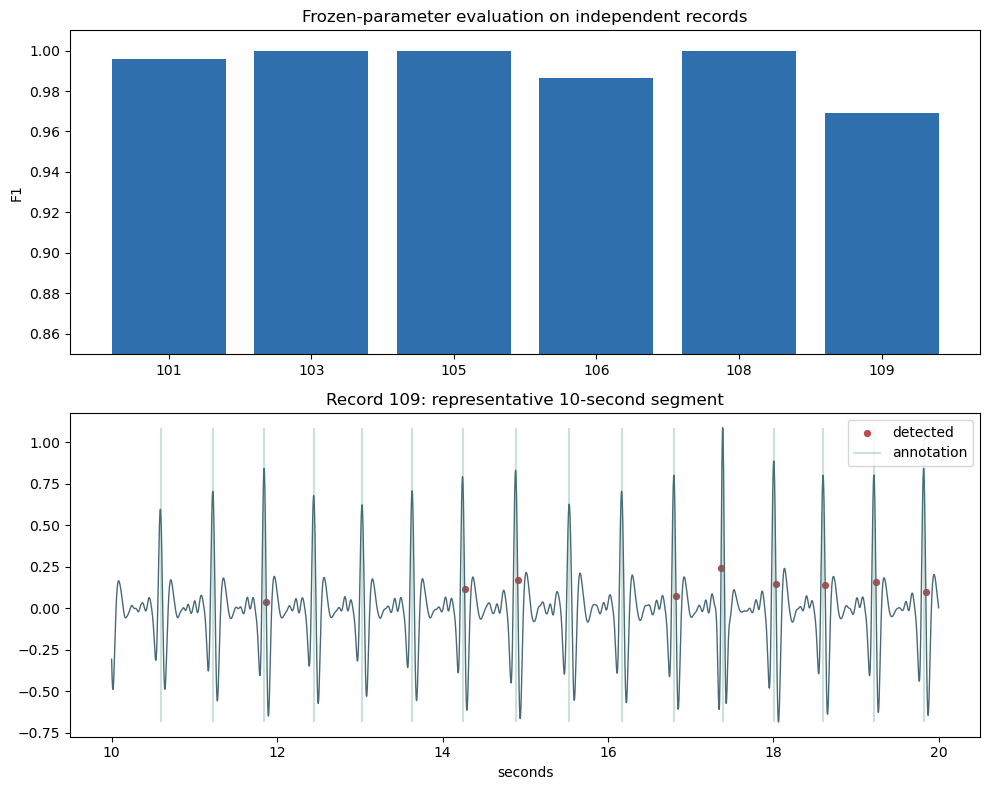

{'development_record': '100',
 'selected_parameters': {'energy_quantile': 0.88,
  'min_distance_seconds': 0.2,
  'matching_tolerance_seconds': 0.1},
 'frozen_test_summary': {'records': 6,
  'sensitivity': 0.983341045812124,
  'positive_predictive_value': 0.999059708509638,
  'f1': 0.9911380597014925,
  'tp': 2125,
  'fp': 2,
  'fn': 36},
 'per_record': [{'record': np.str_('100'),
   'split': 'development',
   'annotated': 371,
   'detected': 371,
   'tp': 371,
   'fp': 0,
   'fn': 0,
   'sensitivity': 1.0,
   'ppv': 1.0,
   'f1': 1.0},
  {'record': np.str_('101'),
   'split': 'frozen test',
   'annotated': 342,
   'detected': 343,
   'tp': 341,
   'fp': 2,
   'fn': 1,
   'sensitivity': 0.9970760233918129,
   'ppv': 0.9941690962099126,
   'f1': 0.9956204379562044},
  {'record': np.str_('103'),
   'split': 'frozen test',
   'annotated': 355,
   'detected': 355,
   'tp': 355,
   'fp': 0,
   'fn': 0,
   'sensitivity': 1.0,
   'ppv': 1.0,
   'f1': 1.0},
  {'record': np.str_('105'),
   'spli

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
test_metrics = metrics[metrics['split'] == 'frozen test']
axes[0].bar(test_metrics['record'], test_metrics['f1'], color='#2f6fae')
axes[0].set(ylim=(0.85, 1.01), ylabel='F1', title='Frozen-parameter evaluation on independent records')
worst_record = str(test_metrics.sort_values('f1').iloc[0]['record'])
worst_index = int(np.where(record_ids == worst_record)[0][0])
filtered, energy, peaks = detect_record(worst_index, best['quantile'], best['min_distance'])
fs = float(sampling_rates[worst_index])
start, stop = int(10 * fs), int(20 * fs)
time = np.arange(start, stop) / fs
axes[1].plot(time, filtered[start:stop], color='#486a78', linewidth=1)
local_peaks = peaks[(peaks >= start) & (peaks < stop)]
local_annotations = np.asarray(annotations[worst_index], dtype=int)
local_annotations = local_annotations[(local_annotations >= start) & (local_annotations < stop)]
axes[1].scatter(local_peaks / fs, filtered[local_peaks], color='#c04b4b', s=18, label='detected')
axes[1].vlines(local_annotations / fs, filtered[start:stop].min(), filtered[start:stop].max(), color='#2f8c67', alpha=0.25, label='annotation')
axes[1].set(xlabel='seconds', title=f'Record {worst_record}: representative 10-second segment')
axes[1].legend()
fig.tight_layout()
fig.savefig(output_dir / 'future09_multirecord_summary.png', dpi=170)
plt.show()
result = {'development_record': '100', 'selected_parameters': {'energy_quantile': best['quantile'], 'min_distance_seconds': best['min_distance'], 'matching_tolerance_seconds': 0.10}, 'frozen_test_summary': test_summary, 'per_record': rows, 'boundary': 'R峰检测课程评价；不等于心律失常分类或临床诊断性能。'}
(output_dir / 'future09_multirecord_result.json').write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
result